<center>

# ***Trabajo Práctico Nro 1 - Continual Learning***

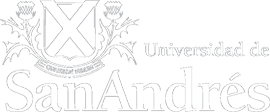

### **Asignatura:** Visión Artificial Avanzada (I309)

### **Alumnos:** Mateo Giacometti y Tiziano Leví Martín Bernal

### **Profesores:** Gastón Castro, Agustín Roca y Francisco Gómez  

### **Fecha:** 30/04/2026

</center>

## Estructura del proyecto (refactor)

Se reorganizo el desarrollo de 4.1 y 4.2 para mejorar mantenibilidad y reutilizacion:
- `src/tp1_cl/data.py`: particion Seq-CIFAR-10, datasets por tarea, replay buffer, transforms.
- `src/tp1_cl/models.py`: backbone + projection head + SupCon loss.
- `src/tp1_cl/train.py`: entrenamiento SupCon y evaluacion lineal.
- `src/tp1_cl/viz.py`: visualizaciones y reduccion 2D.
- `scripts/run_4_1_4_2.py`: ejecucion end-to-end fuera de notebook.

Notebook workflow:
1. Setup e imports.
2. Configuracion y construccion de tareas (4.1).
3. Replay buffer (4.1).
4. Pre-entrenamiento SupCon (4.2).
5. Cabeza lineal y accuracy final (4.2).

### Setup e imports.

In [7]:
import importlib
import os
import sys

import torch
from torch import nn
from torch.utils.data import DataLoader

sys.path.append(os.path.join(os.getcwd(), "src"))

import tp1_cl.data as data_mod
import tp1_cl.models as models_mod
import tp1_cl.train as train_mod
import tp1_cl.viz as viz_mod

importlib.reload(data_mod)
importlib.reload(models_mod)
importlib.reload(train_mod)
importlib.reload(viz_mod)

from tp1_cl.data import (
    CIFAR10_CLASSES,
    ContrastiveTaskDataset,
    LabelMapper,
    ReservoirReplayBuffer,
    SeqCIFAR10Builder,
    TaskConfig,
    TransformConfig,
    TwoCropTransform,
    build_transforms,
)
from tp1_cl.models import SupConLoss, SupConNetwork, build_cifar_resnet
from tp1_cl.train import (
    set_seed,
    train_linear_head,
    train_supcon,
    train_naive_finetuning,
    train_ewc,
)
from tp1_cl.viz import (
    plot_embedding_snapshots,
    plot_linear_history,
    plot_supcon_loss,
    plot_cl_metrics,
)

SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


### Preparación del Dataset

In [2]:
DATA_ROOT = "./data"
BATCH_SIZE = 256
NUM_WORKERS = 8 if torch.cuda.is_available() else 4

DATALOADER_KWARGS = {
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": NUM_WORKERS > 0,
}
if NUM_WORKERS > 0:
    DATALOADER_KWARGS["prefetch_factor"] = 4

transform_config = TransformConfig()
eval_transform, supcon_train_transform = build_transforms(config=transform_config)

task_config = TaskConfig(
    n_tasks=5,
    classes_per_task=2,
    shuffle_class_order=False,
    seed=SEED,
    allow_partial_last_task=False,
    task_classes=None,
    class_order=list(range(10)),
)
seq_builder = SeqCIFAR10Builder(root=DATA_ROOT, config=task_config)

print("4.1 | Seq-CIFAR-10 split summary")
for row in seq_builder.summary_rows():
    print(
        f"Task {row['task_id']}: classes={row['class_names']} "
        f"| train={row['n_train']} | test={row['n_test']}"
    )

task_train_loaders, task_test_loaders = seq_builder.build_task_loaders(
    batch_size=BATCH_SIZE,
    transform=eval_transform,
    train_shuffle=True,
    num_workers=NUM_WORKERS,
    loader_kwargs=DATALOADER_KWARGS,
)

print("\n4.1 | Cada tarea usa su DataLoader propio sin mezclar datos de tareas previas.")
print(f"DataLoader config: {DATALOADER_KWARGS}")

Files already downloaded and verified
Files already downloaded and verified
4.1 | Seq-CIFAR-10 split summary
Task 0: classes=['airplane', 'automobile'] | train=10000 | test=2000
Task 1: classes=['bird', 'cat'] | train=10000 | test=2000
Task 2: classes=['deer', 'dog'] | train=10000 | test=2000
Task 3: classes=['frog', 'horse'] | train=10000 | test=2000
Task 4: classes=['ship', 'truck'] | train=10000 | test=2000

4.1 | Cada tarea usa su DataLoader propio sin mezclar datos de tareas previas.
DataLoader config: {'num_workers': 8, 'pin_memory': True, 'persistent_workers': True, 'prefetch_factor': 4}


### Replay buffer

In [3]:
BUFFER_CAPACITY = 200
replay_buffer = ReservoirReplayBuffer(capacity=BUFFER_CAPACITY, seed=SEED)

demo_images, demo_labels = next(iter(task_train_loaders[0]))
replay_buffer.add(demo_images, demo_labels)
sample_images, sample_labels = replay_buffer.sample(batch_size=16)

print(
    f"4.1 | Replay buffer size={len(replay_buffer)} / {BUFFER_CAPACITY} | "
    f"sample batch={sample_images.shape}, labels={sample_labels.shape}"
)

4.1 | Replay buffer size=200 / 200 | sample batch=torch.Size([16, 3, 32, 32]), labels=torch.Size([16])


In [4]:
task0_classes = seq_builder.task_classes[0]
task0_class_names = [CIFAR10_CLASSES[c] for c in task0_classes]
print(f"4.2 | Task 0 classes: {task0_class_names}")

task0_train_raw = seq_builder.get_task_dataset(task_id=0, train=True, transform=None)
task0_contrastive_dataset = ContrastiveTaskDataset(
    task_dataset=task0_train_raw,
    two_crop_transform=TwoCropTransform(supcon_train_transform),
)
task0_contrastive_loader = DataLoader(
    task0_contrastive_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    **DATALOADER_KWARGS,
)

task0_eval_global = seq_builder.get_task_dataset(task_id=0, train=False, transform=eval_transform)
task0_eval_global_loader = DataLoader(
    task0_eval_global,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **DATALOADER_KWARGS,
)

backbone, feat_dim = build_cifar_resnet(model_name="resnet18")
supcon_model = SupConNetwork(backbone=backbone, feat_dim=feat_dim, proj_dim=128).to(device)
supcon_criterion = SupConLoss(temperature=0.07, base_temperature=0.07)
supcon_optimizer = torch.optim.SGD(
    supcon_model.parameters(),
    lr=0.5,
    momentum=0.9,
    weight_decay=1e-4,
    nesterov=False,
)

4.2 | Task 0 classes: ['airplane', 'automobile']


/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/torch/nn/modules/linear.py:125: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return F.linear(input, self.weight, self.bias)
/home/mateo/Desktop/tp1_vision_artificial_avanzada/src/tp1_cl/models.py:56: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not 

SupCon | Epoch 01/100 | Loss = 6.2871
SupCon | Epoch 02/100 | Loss = 6.1485
SupCon | Epoch 03/100 | Loss = 6.1262
SupCon | Epoch 04/100 | Loss = 6.0865
SupCon | Epoch 05/100 | Loss = 6.0498
SupCon | Epoch 06/100 | Loss = 6.0099
SupCon | Epoch 07/100 | Loss = 5.9696
SupCon | Epoch 08/100 | Loss = 5.9508
SupCon | Epoch 09/100 | Loss = 5.9069
SupCon | Epoch 10/100 | Loss = 5.8869
SupCon | Epoch 11/100 | Loss = 5.8650
SupCon | Epoch 12/100 | Loss = 5.8434
SupCon | Epoch 13/100 | Loss = 5.8304
SupCon | Epoch 14/100 | Loss = 5.8230
SupCon | Epoch 15/100 | Loss = 5.8080
SupCon | Epoch 16/100 | Loss = 5.7983
SupCon | Epoch 17/100 | Loss = 5.7888
SupCon | Epoch 18/100 | Loss = 5.7923
SupCon | Epoch 19/100 | Loss = 5.7730
SupCon | Epoch 20/100 | Loss = 5.7759
SupCon | Epoch 21/100 | Loss = 5.7702
SupCon | Epoch 22/100 | Loss = 5.7579
SupCon | Epoch 23/100 | Loss = 5.7486
SupCon | Epoch 24/100 | Loss = 5.7495
SupCon | Epoch 25/100 | Loss = 5.7613
SupCon | Epoch 26/100 | Loss = 5.7524
SupCon | Epo

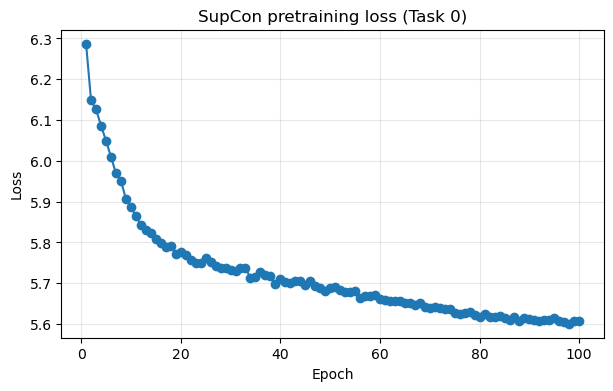

/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


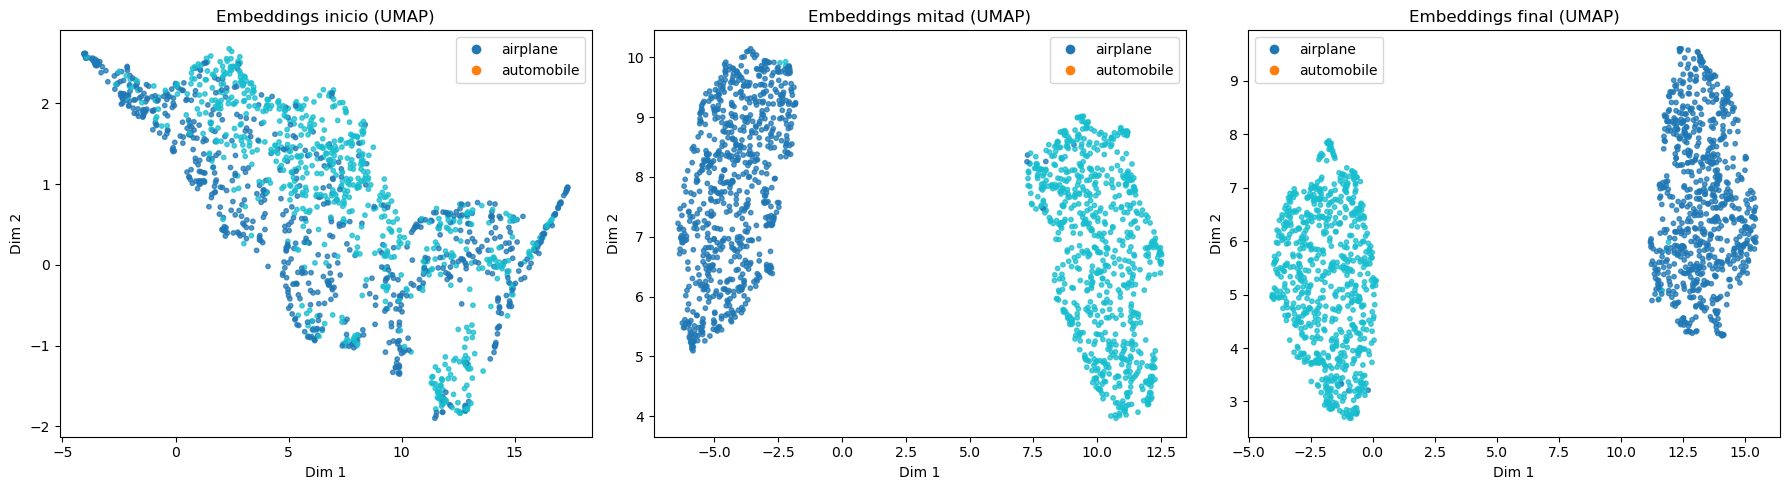

In [5]:
import math

SUPCON_EPOCHS = 100
WARMUP_EPOCHS = 10   #min(10, max(1, SUPCON_EPOCHS // 10))
snapshot_epochs = {max(1, SUPCON_EPOCHS // 2): "mitad", SUPCON_EPOCHS: "final"}

def supcon_lr_lambda(epoch: int) -> float:
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(WARMUP_EPOCHS)
    if SUPCON_EPOCHS == WARMUP_EPOCHS:
        return 1.0
    progress = float(epoch - WARMUP_EPOCHS) / float(SUPCON_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

supcon_scheduler = torch.optim.lr_scheduler.LambdaLR(
    supcon_optimizer, lr_lambda=supcon_lr_lambda
)

supcon_losses, embedding_snapshots = train_supcon(
    model=supcon_model,
    train_loader=task0_contrastive_loader,
    eval_loader_for_snapshots=task0_eval_global_loader,
    criterion=supcon_criterion,
    optimizer=supcon_optimizer,
    scheduler=supcon_scheduler,
    device=device,
    epochs=SUPCON_EPOCHS,
    snapshot_epochs=snapshot_epochs,
)

plot_supcon_loss(supcon_losses)
plot_embedding_snapshots(
    snapshots=embedding_snapshots,
    task_classes=task0_classes,
    class_names=task0_class_names,
    seed=SEED,
)

/home/mateo/miniconda3/envs/workspace/lib/python3.11/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at ../aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Linear Eval | epoch 01/100 | train_loss=0.0364 | train_acc=98.08% | test_acc=99.30%
Linear Eval | epoch 02/100 | train_loss=0.0047 | train_acc=99.97% | test_acc=99.40%
Linear Eval | epoch 03/100 | train_loss=0.0024 | train_acc=99.98% | test_acc=99.40%
Linear Eval | epoch 04/100 | train_loss=0.0013 | train_acc=99.99% | test_acc=99.30%
Linear Eval | epoch 05/100 | train_loss=0.0011 | train_acc=99.99% | test_acc=99.30%
Linear Eval | epoch 06/100 | train_loss=0.0010 | train_acc=99.98% | test_acc=99.30%
Linear Eval | epoch 07/100 | train_loss=0.0011 | train_acc=99.98% | test_acc=99.25%
Linear Eval | epoch 08/100 | train_loss=0.0009 | train_acc=99.99% | test_acc=99.30%
Linear Eval | epoch 09/100 | train_loss=0.0008 | train_acc=99.98% | test_acc=99.30%
Linear Eval | epoch 10/100 | train_loss=0.0007 | train_acc=99.98% | test_acc=99.30%
Linear Eval | epoch 11/100 | train_loss=0.0006 | train_acc=99.99% | test_acc=99.30%
Linear Eval | epoch 12/100 | train_loss=0.0004 | train_acc=99.99% | test_acc

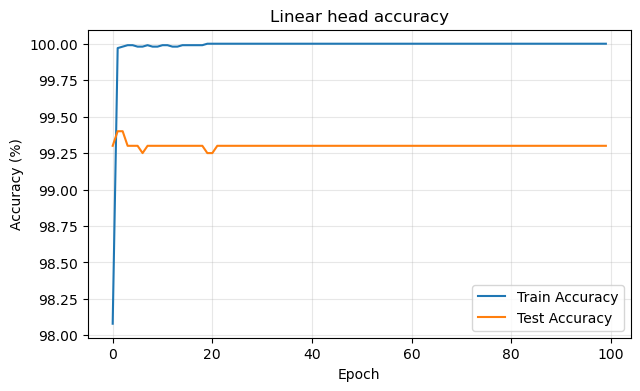

4.2 | Best Task 0 test accuracy (linear head): 99.40%
4.2 | Final Task 0 test accuracy (linear head): 99.30%


In [6]:
label_mapper_task0 = LabelMapper(task_classes=task0_classes)
task0_train_linear = seq_builder.get_task_dataset(
    task_id=0,
    train=True,
    transform=eval_transform,
    target_transform=label_mapper_task0,
)
task0_test_linear = seq_builder.get_task_dataset(
    task_id=0,
    train=False,
    transform=eval_transform,
    target_transform=label_mapper_task0,
)

task0_train_linear_loader = DataLoader(
    task0_train_linear,
    batch_size=BATCH_SIZE,
    shuffle=True,
    **DATALOADER_KWARGS,
)
task0_test_linear_loader = DataLoader(
    task0_test_linear,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **DATALOADER_KWARGS,
)

LINEAR_EPOCHS = 100
LINEAR_LR = 1.0 if LINEAR_EPOCHS >= 100 else 0.1
LINEAR_MILESTONES = [
    max(1, int(LINEAR_EPOCHS * 0.60)),
    max(1, int(LINEAR_EPOCHS * 0.75)),
    max(1, int(LINEAR_EPOCHS * 0.90)),
]

linear_head = nn.Linear(feat_dim, len(task0_classes)).to(device)
linear_history, task0_best_test_accuracy = train_linear_head(
    backbone=supcon_model.backbone,
    linear_head=linear_head,
    train_loader=task0_train_linear_loader,
    test_loader=task0_test_linear_loader,
    device=device,
    epochs=LINEAR_EPOCHS,
    lr=LINEAR_LR,
    scheduler_milestones=LINEAR_MILESTONES,
    scheduler_gamma=0.2,
    report_best=True,
)

plot_linear_history(linear_history)
print(f"4.2 | Best Task 0 test accuracy (linear head): {task0_best_test_accuracy:.2f}%")
print(f"4.2 | Final Task 0 test accuracy (linear head): {linear_history['test_acc'][-1]:.2f}%")

### 4.3.1 Fine-Tuning Naive (Baseline)
Entrenamiento secuencial de las 5 tareas con entropía cruzada, sin mitigación del olvido.

Task 0 | Epoch 01/30 | train_loss=0.1445
Task 0 | Epoch 02/30 | train_loss=0.0039
Task 0 | Epoch 03/30 | train_loss=0.0026
Task 0 | Epoch 04/30 | train_loss=0.0098
Task 0 | Epoch 05/30 | train_loss=0.0049
Task 0 | Epoch 06/30 | train_loss=0.0031
Task 0 | Epoch 07/30 | train_loss=0.0026
Task 0 | Epoch 08/30 | train_loss=0.0025
Task 0 | Epoch 09/30 | train_loss=0.0025
Task 0 | Epoch 10/30 | train_loss=0.0024
Task 0 | Epoch 11/30 | train_loss=0.0021
Task 0 | Epoch 12/30 | train_loss=0.0021
Task 0 | Epoch 13/30 | train_loss=0.0037
Task 0 | Epoch 14/30 | train_loss=0.0027
Task 0 | Epoch 15/30 | train_loss=0.0026
Task 0 | Epoch 16/30 | train_loss=0.0025
Task 0 | Epoch 17/30 | train_loss=0.0020
Task 0 | Epoch 18/30 | train_loss=0.0021
Task 0 | Epoch 19/30 | train_loss=0.0020
Task 0 | Epoch 20/30 | train_loss=0.0019
Task 0 | Epoch 21/30 | train_loss=0.0020
Task 0 | Epoch 22/30 | train_loss=0.0018
Task 0 | Epoch 23/30 | train_loss=0.0017
Task 0 | Epoch 24/30 | train_loss=0.0019
Task 0 | Epoch 2

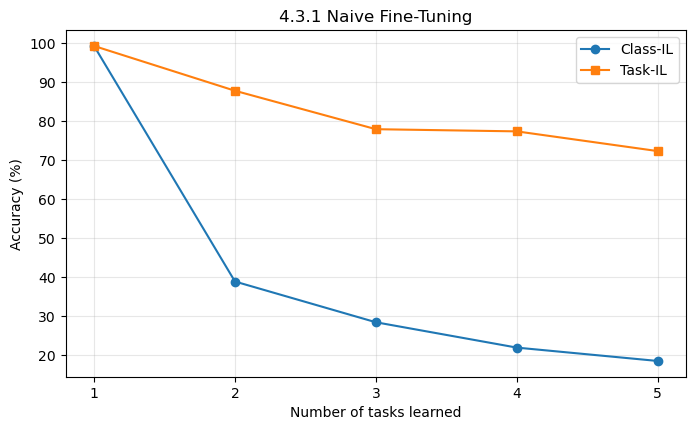

Naive final Class-IL: 18.48%
Naive final Task-IL: 72.36%


In [8]:
CL_EPOCHS_PER_TASK = 30
CL_NUM_CLASSES = len(CIFAR10_CLASSES)
NAIVE_LR = 0.03
NAIVE_MOMENTUM = 0.9
NAIVE_WEIGHT_DECAY = 1e-4

naive_model, naive_history = train_naive_finetuning(
    backbone=supcon_model.backbone,
    feat_dim=feat_dim,
    train_loaders=task_train_loaders,
    test_loaders=task_test_loaders,
    task_classes=seq_builder.task_classes,
    device=device,
    num_classes=CL_NUM_CLASSES,
    epochs_per_task=CL_EPOCHS_PER_TASK,
    lr=NAIVE_LR,
    momentum=NAIVE_MOMENTUM,
    weight_decay=NAIVE_WEIGHT_DECAY,
    verbose=True,
)

plot_cl_metrics(naive_history, title="4.3.1 Naive Fine-Tuning")
print(f"Naive final Class-IL: {naive_history['class_il'][-1]:.2f}%")
print(f"Naive final Task-IL: {naive_history['task_il'][-1]:.2f}%")

### 4.3.2 Elastic Weight Consolidation (EWC)
Entrenamiento secuencial con penalización EWC usando diagonal de Fisher acumulada por tarea.

Task 0 | Epoch 01/30 | train_loss=0.1335
Task 0 | Epoch 02/30 | train_loss=0.0031
Task 0 | Epoch 03/30 | train_loss=0.0030
Task 0 | Epoch 04/30 | train_loss=0.0034
Task 0 | Epoch 05/30 | train_loss=0.0027
Task 0 | Epoch 06/30 | train_loss=0.0031
Task 0 | Epoch 07/30 | train_loss=0.0028
Task 0 | Epoch 08/30 | train_loss=0.0022
Task 0 | Epoch 09/30 | train_loss=0.0021
Task 0 | Epoch 10/30 | train_loss=0.0024
Task 0 | Epoch 11/30 | train_loss=0.0040
Task 0 | Epoch 12/30 | train_loss=0.0021
Task 0 | Epoch 13/30 | train_loss=0.0019
Task 0 | Epoch 14/30 | train_loss=0.0022
Task 0 | Epoch 15/30 | train_loss=0.0021
Task 0 | Epoch 16/30 | train_loss=0.0018
Task 0 | Epoch 17/30 | train_loss=0.0046
Task 0 | Epoch 18/30 | train_loss=0.0017
Task 0 | Epoch 19/30 | train_loss=0.0021
Task 0 | Epoch 20/30 | train_loss=0.0018
Task 0 | Epoch 21/30 | train_loss=0.0018
Task 0 | Epoch 22/30 | train_loss=0.0016
Task 0 | Epoch 23/30 | train_loss=0.0117
Task 0 | Epoch 24/30 | train_loss=0.0043
Task 0 | Epoch 2

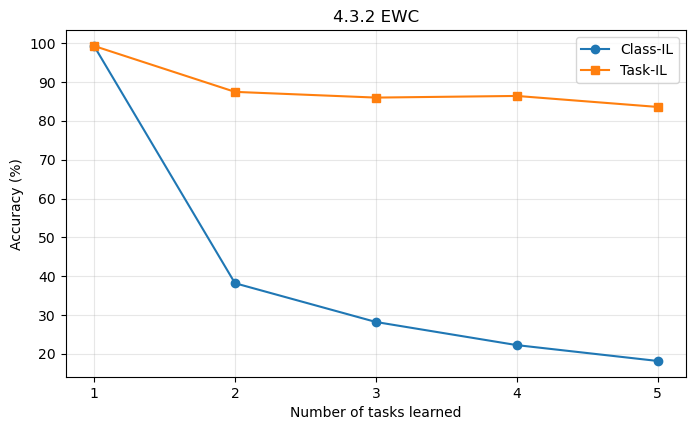

EWC final Class-IL: 18.14%
EWC final Task-IL: 83.59%


In [9]:
EWC_EPOCHS_PER_TASK = 30
EWC_LR = 0.03
EWC_MOMENTUM = 0.9
EWC_WEIGHT_DECAY = 1e-4
EWC_LAMBDA = 25.0
EWC_FISHER_MAX_BATCHES = 100

ewc_model, ewc_history = train_ewc(
    backbone=supcon_model.backbone,
    feat_dim=feat_dim,
    train_loaders=task_train_loaders,
    test_loaders=task_test_loaders,
    task_classes=seq_builder.task_classes,
    device=device,
    num_classes=CL_NUM_CLASSES,
    epochs_per_task=EWC_EPOCHS_PER_TASK,
    lr=EWC_LR,
    momentum=EWC_MOMENTUM,
    weight_decay=EWC_WEIGHT_DECAY,
    ewc_lambda=EWC_LAMBDA,
    fisher_max_batches=EWC_FISHER_MAX_BATCHES,
    verbose=True,
)

plot_cl_metrics(ewc_history, title="4.3.2 EWC")
print(f"EWC final Class-IL: {ewc_history['class_il'][-1]:.2f}%")
print(f"EWC final Task-IL: {ewc_history['task_il'][-1]:.2f}%")